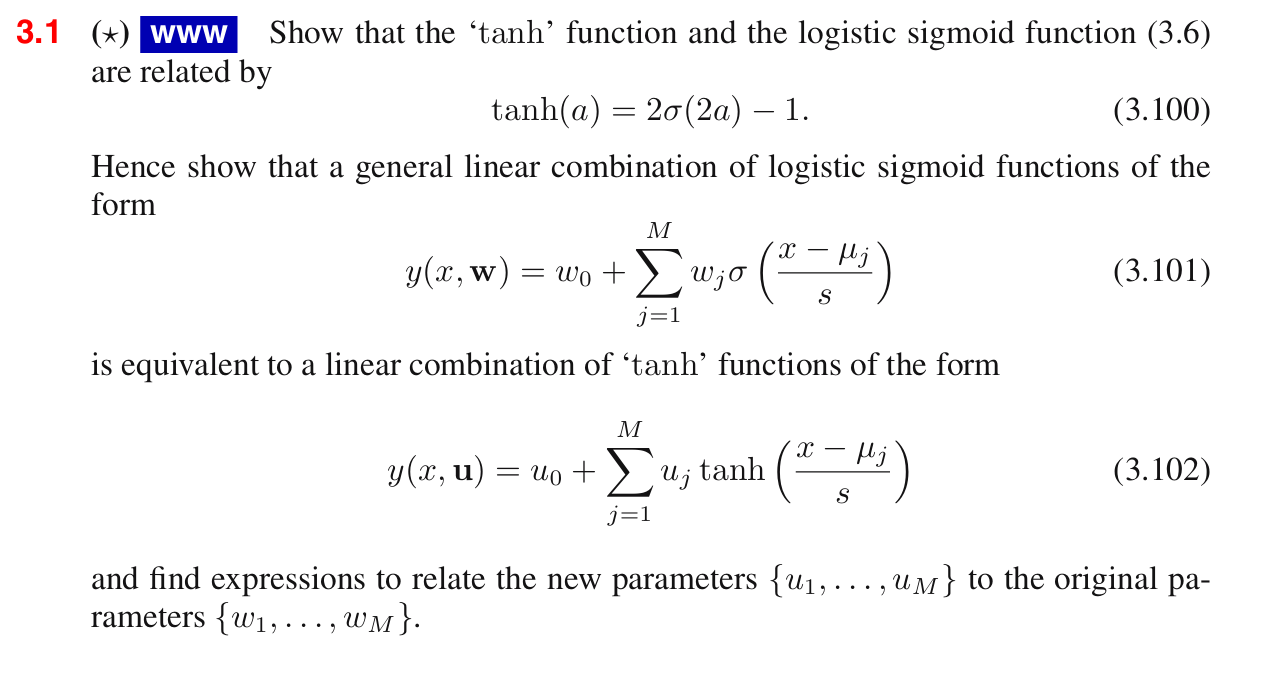

Recall the tanh function:
\begin{align*}
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
\end{align*}
And the sigmoid function:
\begin{align*}
\sigma(x) &= \frac{1}{1 + e^{-x}} 
\end{align*}
We can express the tanh function in terms of the sigmoid function as follows:
\begin{align*}
\tanh(x) &= \frac{e^x - e^{-x}}{e^x + e^{-x}} \\
&= \frac{e^x - e^{-x}}{e^x + e^{-x}} \cdot \frac{e^x + e^{-x}}{e^x + e^{-x}} \\
&= \frac{e^{2x} - 1}{e^{2x} + 1} \\
&= \frac{2e^{2x}}{e^{2x} + 1} - 1 \\
&= 2 \cdot \sigma(2x) - 1
\end{align*}

Therefore, we have the following:
\begin{align*}
y(x, \mathbf{u}) &= u_0 + \sum_{j=1}^M u_j \tanh(\frac{x - u_j}{s}) \\
&= u_0 + \sum_{j=1}^M u_j (2 \cdot \sigma(\frac{2(x - u_j)}{s}) - 1) \\
&= u_0 + \sum_{j=1}^M 2u_j \cdot \sigma(\frac{x - u_j}{s/2}) - \sum_{j=1}^M u_j \\
&= (u_0 - \sum_{j=1}^M u_j) + \sum_{j=1}^M 2u_j \cdot \sigma(\frac{x - u_j}{s/2})
\end{align*}

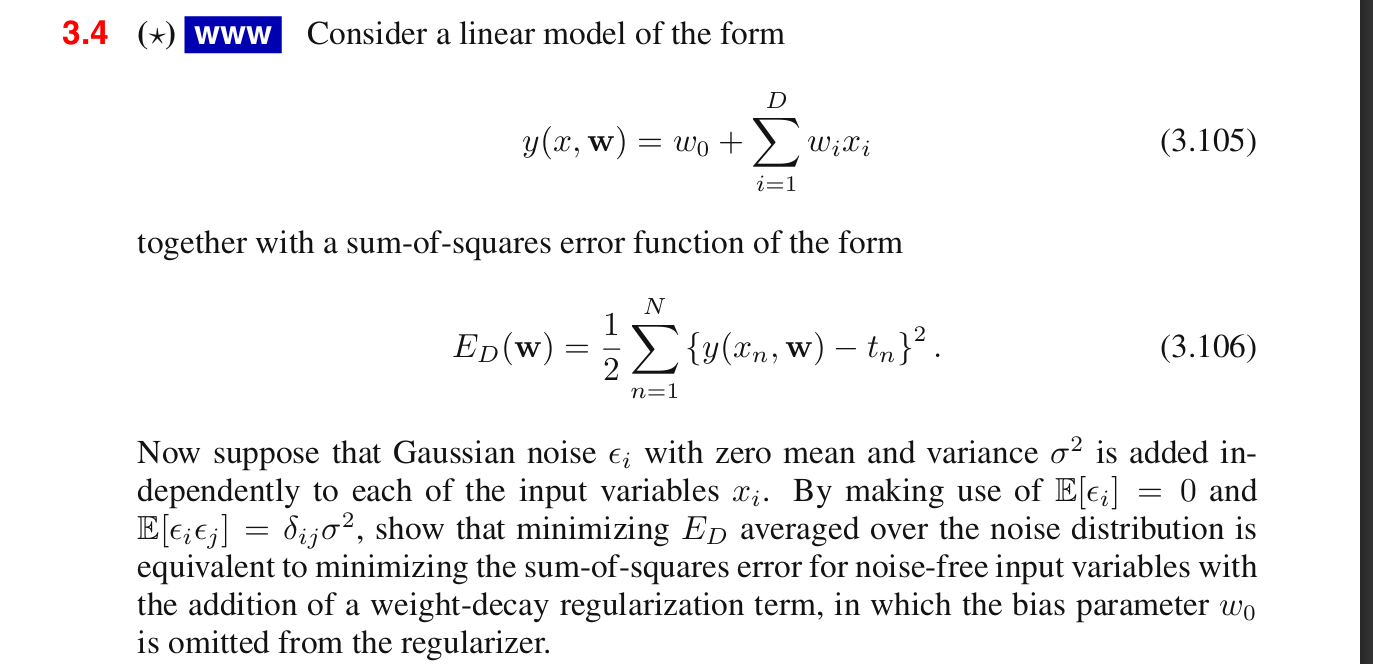

With the noise $\epsilon_i$ added to the output, we can express the model as follows:
\begin{align*}
y(x_i+\epsilon_i, \mathbf{w}) &= w_0 + \sum_{i=1}^D w_i(x_i + \epsilon_i) \\&= w_0 + \sum_{i=1}^D w_i x_i + \sum_{i=1}^D w_i \epsilon_i \\&= y(x_i, \mathbf{w}) + \sum_{i=1}^D w_i \epsilon_i\\&= y(x_i, \mathbf{w}) + e_i
\end{align*}

Then the sum of squared errors can be expressed as follows:
\begin{align*}
E_D(\mathbf{w}) &= \frac{1}{2} \sum_{i=1}^N (y(x_i + \epsilon_i, \mathbf{w}) - t_i)^2 \\
&= \frac{1}{2} \sum_{i=1}^N (y(x_i, \mathbf{w}) + e_i - t_i)^2 \\
&= \frac{1}{2} \sum_{i=1}^N (y(x_i, \mathbf{w}) - t_i)^2 + \sum_{i=1}^N e_i (y(x_i, \mathbf{w}) - t_i) + \frac{1}{2} \sum_{i=1}^N e_i^2
\end{align*}

The expected value of the sum of squared errors:
\begin{align*}
\mathbb{E}[E_D(\mathbf{w})] &= \frac{1}{2} \sum_{i=1}^N (y(x_i, \mathbf{w}) - t_i)^2 + \sum_{i=1}^N \mathbb{E}[e_i] (y(x_i, \mathbf{w}) - t_i) + \frac{1}{2} \sum_{i=1}^N \mathbb{E}[e_i^2] 
\end{align*}

Since $\epsilon_i$ is a zero-mean Gaussian noise, we have $\mathbb{E}[e_i] = 0$. Now we evaluate $\mathbb{E}[e_i^2]$:
\begin{align*}
\mathbb{E}[e_i^2] &= \mathbb{E}[(\sum_{j=1}^D w_j \epsilon_j)(\sum_{k=1}^D w_k \epsilon_k)] \\
&= \sum_{j=1}^D \sum_{k=1}^D w_j w_k \mathbb{E}[\epsilon_j \epsilon_k] \\
&= \sum_{j=1}^D w_j^2 \sigma^2
\end{align*}
Since we have $\mathbb{E}[\epsilon_j \epsilon_k] = 0$ for $j \neq k$ and $\mathbb{E}[\epsilon_j^2] = \sigma^2$.
Therefore, we can express the expected value of the sum of squared errors as follows:
\begin{align*}
\mathbb{E}[E_D(\mathbf{w})] &= \frac{1}{2} \sum_{i=1}^N (y(x_i, \mathbf{w}) - t_i)^2 + \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^D w_j^2 \sigma^2 \\
&= \frac{1}{2} \sum_{i=1}^N (y(x_i, \mathbf{w}) - t_i)^2 + \frac{N \sigma^2}{2} \sum_{j=1}^D w_j^2 
\end{align*}


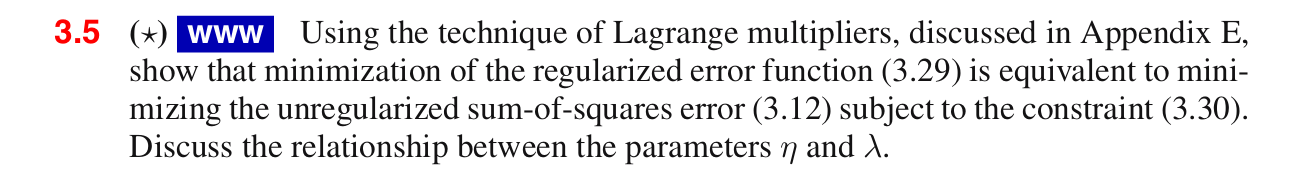

Let recall the unregularized error function:
\begin{align*}
E_D(\mathbf{w}) = \frac{1}{2} \sum_{i=1}^N (y(x_i, \mathbf{w}) - t_i)^2
\end{align*}
And the constraint function:
\begin{align*}
E_W(\mathbf{w}) = \frac{1}{2} \sum_{j=1}^D w_j^2 
\end{align*}
The goal is to minimize $E_D(\mathbf{w})$ subject to the constraint $E_W(\mathbf{w}) \leq \eta$. We can use the method of Lagrange multipliers:
\begin{align*}
\mathcal{L}(\mathbf{w}, \lambda) &= E_D(\mathbf{w}) + \lambda (E_W(\mathbf{w}) - \eta)\\
&= \frac{1}{2} \sum_{i=1}^N (y(x_i, \mathbf{w}) - t_i)^2 + \lambda \frac{1}{2} \sum_{j=1}^D w_j^2 - \lambda \eta
\end{align*}
When we expand the Lagrangian, we can see that it is equivalent to the regularized error function since $\lambda \eta$ is a constant and does not affect the optimization process. 

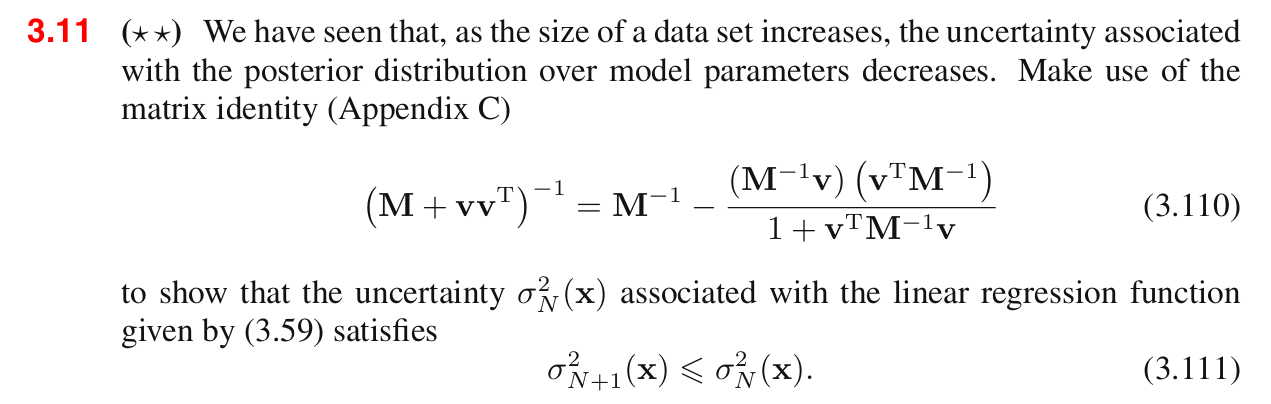

The posterior covariance matrix $\mathbf{S}_N$ is given by:
\begin{align*}
\mathbf{S}_N^{-1} = \alpha \mathbf{I} + \beta \mathbf{\Phi}^T \mathbf{\Phi}
\end{align*}
So we can express $\mathbf{S}_{N+1} $ as follows:
\begin{align*}
\mathbf{S}_{N+1}^{-1} = \mathbf{S}_N^{-1} + \beta \mathbf{\phi}(x_{N+1}) \mathbf{\phi}(x_{N+1})^T
\end{align*}

We use the identity:
\begin{align*}
(\mathbf{A} + \mathbf{v} \mathbf{v}^T)^{-1} = \mathbf{A}^{-1} - \frac{\mathbf{A}^{-1} \mathbf{v} \mathbf{v}^T \mathbf{A}^{-1}}{1 + \mathbf{v}^T \mathbf{A}^{-1} \mathbf{v}}
\end{align*}
With $\mathbf{A} = \mathbf{S}_N^{-1}$ and $\mathbf{v} = \sqrt{\beta} \mathbf{\phi}(x_{N+1}) =\sqrt{\beta} \mathbf{\phi}_{N+1}$, we can express $\mathbf{S}_{N+1}$ as follows:
\begin{align*}
\mathbf{S}_{N+1} &= (\mathbf{S}_N^{-1} + \beta \mathbf{\phi}_{N+1} \mathbf{\phi}_{N+1}^T)^{-1} \\
&= \mathbf{S}_N - \frac{\mathbf{S}_N \beta \mathbf{\phi}_{N+1} \mathbf{\phi}_{N+1}^T \mathbf{S}_N}{1 + \beta \mathbf{\phi}_{N+1}^T \mathbf{S}_N \mathbf{\phi}_{N+1}}
\end{align*}

Then the prediction variance is given by:
\begin{align*}
\sigma_{N+1}^2(x) &= \frac{1}{\beta} + \mathbf{\phi}(x)^T \mathbf{S}_{N+1} \mathbf{\phi}(x) \\
&= \frac{1}{\beta} + \mathbf{\phi}(x)^T\left( \mathbf{S}_N - \frac{\mathbf{S}_N \beta \mathbf{\phi}_{N+1} \mathbf{\phi}_{N+1}^T \mathbf{S}_N}{1 + \beta \mathbf{\phi}_{N+1}^T \mathbf{S}_N \mathbf{\phi}_{N+1}} \right) \mathbf{\phi}(x) \\
&= \frac{1}{\beta} + \mathbf{\phi}(x)^T \mathbf{S}_N \mathbf{\phi}(x) - \frac{\beta (\mathbf{\phi}(x)^T \mathbf{S}_N \mathbf{\phi}_{N+1})^2}{1 + \beta \mathbf{\phi}_{N+1}^T \mathbf{S}_N \mathbf{\phi}_{N+1}}\\
&= \sigma_N^2(x) - \frac{\beta (\mathbf{\phi}(x)^T \mathbf{S}_N \mathbf{\phi}_{N+1})^2}{1 + \beta \mathbf{\phi}_{N+1}^T \mathbf{S}_N \mathbf{\phi}_{N+1}}
\end{align*}

Note that $\beta > 0$, $1 + \beta \mathbf{\phi}_{N+1}^T \mathbf{S}_N \mathbf{\phi}_{N+1} > 0$ and $\mathbf{S}_N$ is a positive definite matrix, so we have $\sigma_{N+1}^2(x) < \sigma_N^2(x)$.


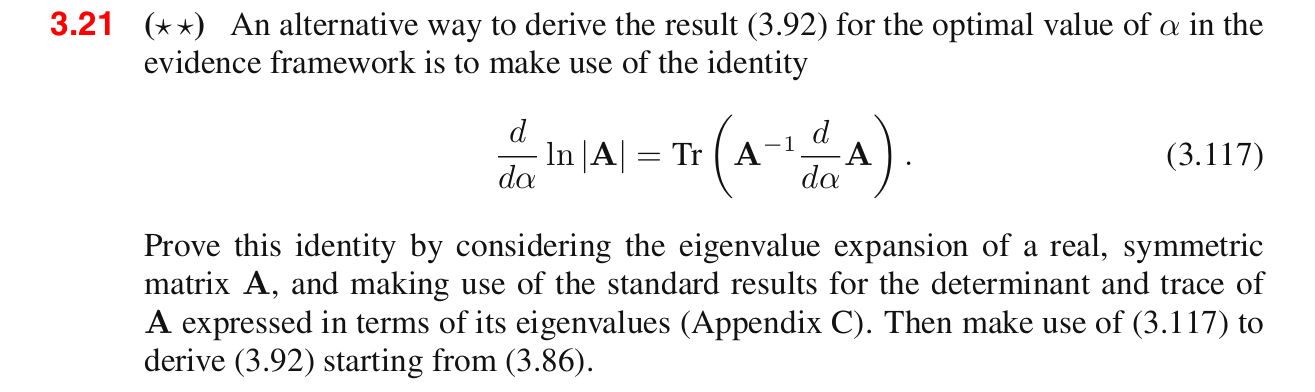